In [43]:
import pandas as pd

deliveries_df = pd.read_csv('/content/EDA-IPL/data/deliveries.csv')
matches_df = pd.read_csv('/content/EDA-IPL/data/matches.csv')

deliveries_df.head()
matches_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [38]:
first_innings_scores = deliveries_df[deliveries_df['inning'] == 1].groupby(['match_id', 'batting_team'])['total_runs'].sum().reset_index()
print('First 5 rows of first_innings_scores:')
display(first_innings_scores.head())

First 5 rows of first_innings_scores:


,match_id,batting_team,total_runs
0,335982,Kolkata Knight Riders,222
1,335983,Chennai Super Kings,240
2,335984,Rajasthan Royals,129
3,335985,Mumbai Indians,165
4,335986,Deccan Chargers,110


In [39]:
merged_scores = pd.merge(first_innings_scores, matches_df[['id', 'match_type']], left_on='match_id', right_on='id', how='left')
merged_scores['match_phase'] = merged_scores['match_type'].apply(lambda x: 'Playoff/Final' if x == 'Eliminator' or x == 'Qualifier 1' or x == 'Qualifier 2' or x == 'Final' else 'Regular Season')
print('First 5 rows of merged_scores with match phase:')
display(merged_scores.head())

First 5 rows of merged_scores with match phase:


,match_id,batting_team,total_runs,id,match_type,match_phase
0,335982,Kolkata Knight Riders,222,335982,League,Regular Season
1,335983,Chennai Super Kings,240,335983,League,Regular Season
2,335984,Rajasthan Royals,129,335984,League,Regular Season
3,335985,Mumbai Indians,165,335985,League,Regular Season
4,335986,Deccan Chargers,110,335986,League,Regular Season


In [40]:
average_scores_distribution = merged_scores.groupby(['batting_team', 'match_phase'])['total_runs'].mean().reset_index()
print('Average 1st Innings Score Distribution:')
display(average_scores_distribution.head())

Average 1st Innings Score Distribution:


,batting_team,match_phase,total_runs
0,Chennai Super Kings,Playoff/Final,181.666667
1,Chennai Super Kings,Regular Season,169.066116
2,Deccan Chargers,Playoff/Final,143.000000
3,Deccan Chargers,Regular Season,157.666667
4,Delhi Capitals,Playoff/Final,159.800000


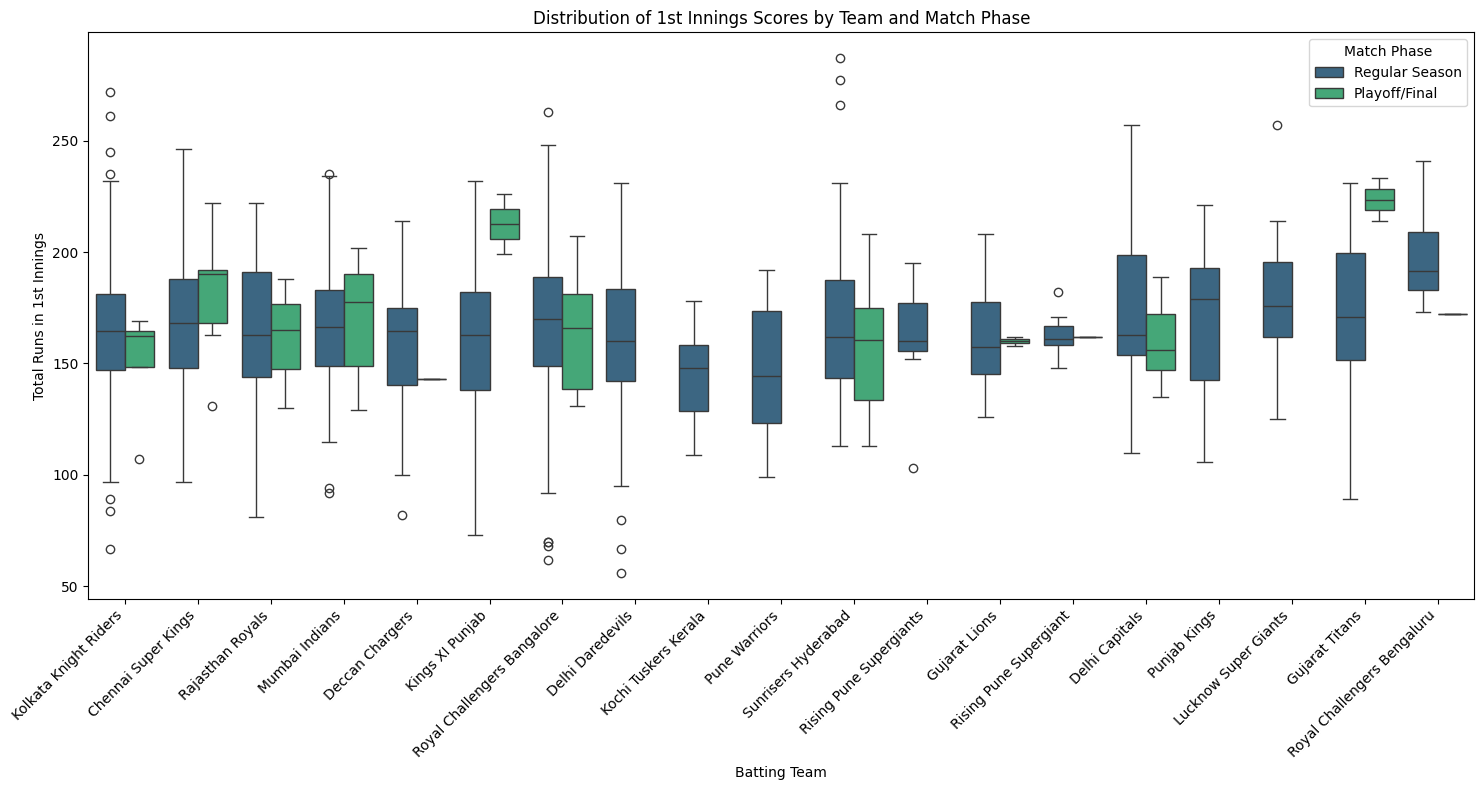

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.boxplot(x='batting_team', y='total_runs', hue='match_phase', data=merged_scores, palette='viridis')
plt.title('Distribution of 1st Innings Scores by Team and Match Phase')
plt.xlabel('Batting Team')
plt.ylabel('Total Runs in 1st Innings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Match Phase')
plt.tight_layout()
plt.show()